In [170]:
import sqlite3
import pandas as pd 
connect_sqlite = sqlite3.connect("valorant.sqlite")
games = pd.read_sql_query("SELECT * FROM Games", con=connect_sqlite)
game_scoreboard = pd.read_sql_query("SELECT * FROM Game_Scoreboard", con=connect_sqlite)


In [171]:
merged = pd.merge(game_scoreboard[["GameID", "Agent","TeamAbbreviation"]], games[["GameID","Team1","Team2","Winner"]], on="GameID")

### Finding uncorrect matches

In [172]:
import collections
indexs = collections.defaultdict(int)

for id,row in merged.iterrows():
    indexs[row["GameID"]] += 1

errors = []
for key,value in indexs.items():
    if value != 10:
        errors.append(key)

len(errors)

209

In [173]:
merged

,GameID,Agent,TeamAbbreviation,Team1,Team2,Winner
0,60894,jett,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming
1,60894,chamber,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming
2,60894,sova,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming
3,60894,viper,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming
4,60894,skye,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming
...,...,...,...,...,...,...
157934,13,,,Dignitas,JSD,JSD
157935,13,,,Dignitas,JSD,JSD
157936,13,,,Dignitas,JSD,JSD
157937,13,,,Dignitas,JSD,JSD


In [174]:
deleting_rows = merged[merged["GameID"].isin(errors)].index
merged.drop(deleting_rows, inplace=True)
deleting_rows = merged[merged["Agent"] == ""].index
merged.drop(deleting_rows, inplace=True)
deleting_rows = merged[merged["GameID"] == "2000"].index
merged.drop(deleting_rows, inplace=True)
deleting_rows = merged[merged["GameID"] == "1618"].index
merged.drop(deleting_rows, inplace=True)
merged.reset_index(inplace=True)



### Syncing team abbreviation w/ team name

In [175]:
import numpy as np
merged["thisteam"] = np.nan
for id,row in merged.iterrows():
    if id%10 <= 4:
        merged.loc[id,"thisteam"] = row["Team1"]
    else:
        merged.loc[id,"thisteam"] = row["Team2"]

C:\Users\user\AppData\Local\Temp\ipykernel_4704\1245820542.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Booster Seat Gaming' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  merged.loc[id,"thisteam"] = row["Team1"]


In [176]:
merged

,index,GameID,Agent,TeamAbbreviation,Team1,Team2,Winner,thisteam
0,0,60894,jett,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming,Booster Seat Gaming
1,1,60894,chamber,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming,Booster Seat Gaming
2,2,60894,sova,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming,Booster Seat Gaming
3,3,60894,viper,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming,Booster Seat Gaming
4,4,60894,skye,Boos,Booster Seat Gaming,Pho Real,Booster Seat Gaming,Booster Seat Gaming
...,...,...,...,...,...,...,...,...
152745,157149,221,sage,WP,NeverEndingStory,Worst Players,Worst Players,Worst Players
152746,157150,221,phoenix,WP,NeverEndingStory,Worst Players,Worst Players,Worst Players
152747,157151,221,cypher,WP,NeverEndingStory,Worst Players,Worst Players,Worst Players
152748,157152,221,sova,WP,NeverEndingStory,Worst Players,Worst Players,Worst Players


In [191]:
pickrate = merged["Agent"].value_counts().reset_index()
pickrate["percent"] = pickrate["count"] / 30550 * 100
pickrate

,Agent,count,percent
0,sova,23077,75.538462
1,jett,22180,72.602291
2,omen,15261,49.954173
3,cypher,13241,43.342062
4,raze,12828,41.990180
5,killjoy,11511,37.679214
6,sage,10184,33.335516
7,astra,8115,26.563011
8,viper,7606,24.896890
9,breach,7133,23.348609


In [186]:
wins = merged[merged["Winner"] == merged["thisteam"]]["Agent"].value_counts()
loses = merged[merged["Winner"] != merged["thisteam"]]["Agent"].value_counts()

winrate = pd.merge(wins,loses, on="Agent", suffixes=["_wins","_loses"], how="outer").reset_index()
winrate.fillna(0, inplace=True)
winrate["percent"] = winrate["count_wins"]/(winrate["count_loses"]+winrate["count_wins"])*100
winrate.replace(np.inf, 100, inplace=True)
winrate

,Agent,count_wins,count_loses,percent
0,astra,4148,3967,51.115219
1,breach,3395,3738,47.595682
2,brimstone,1502,1542,49.342970
3,chamber,108,84,56.250000
4,cypher,6540,6701,49.392040
5,jett,11073,11107,49.923354
6,kayo,509,560,47.614593
7,killjoy,5852,5659,50.838329
8,omen,7562,7699,49.551143
9,phoenix,2110,2198,48.978644


### sending sql files

In [187]:
merged.to_sql(con=connect_sqlite, index=True, name="merged_test1", if_exists="replace")

152750

In [192]:

pickrate.to_sql(con=connect_sqlite, index=True, name="pickrate", if_exists="replace")
winrate.to_sql(con=connect_sqlite, index=True, name="winrate", if_exists="replace")

17

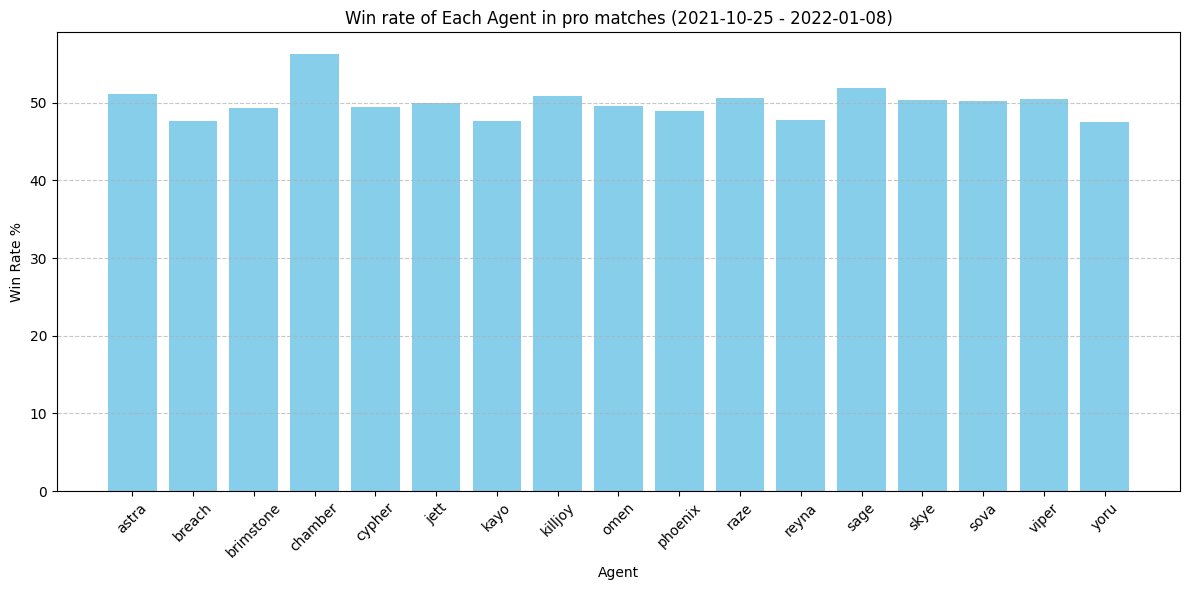

In [182]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.bar(winrate["Agent"], winrate["percent"], color='skyblue')
plt.title('Win rate of Each Agent in pro matches (2021-10-25 - 2022-01-08)')
plt.xlabel('Agent')
plt.ylabel('Win Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


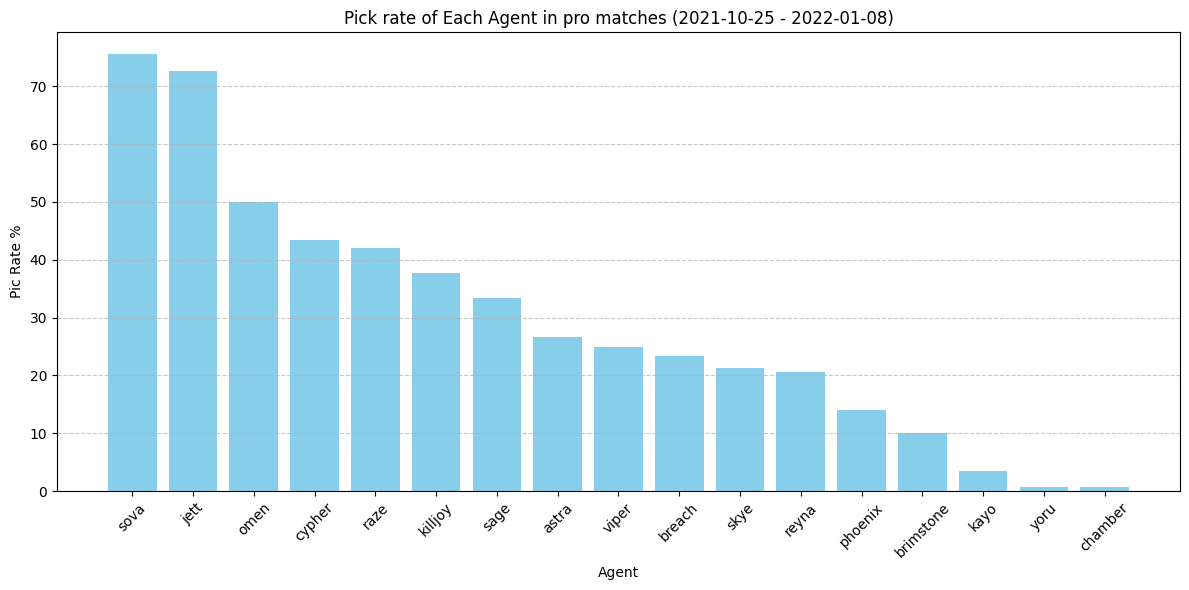

In [193]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 6))
plt.bar(pickrate["Agent"], pickrate["percent"], color='skyblue')
plt.title('Pick rate of Each Agent in pro matches (2021-10-25 - 2022-01-08)')
plt.xlabel('Agent')
plt.ylabel('Pic Rate %')
plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
